In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
cc_data=pd.read_csv("cc_data.csv")

In [4]:
cc_data.head()

,index,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,151888,2019/03/23 03:06,3.586010e+15,"fraud_Ferry, Lynch and Kautzer",misc_net,1.24,Crystal,Fuller,F,000 Jennifer Mills,...,47.4974,-122.0107,50489,Osteopath,1984/02/29,ff66e2310bf7a2a05e65d6b0a363aa5b,1332471978,47.352172,-121.644080,0
1,1185025,2020/05/10 11:28,4.671730e+15,fraud_Bogisich Inc,grocery_pos,112.57,Kenneth,Edwards,M,3653 Ryan Crossroad,...,40.8618,-85.6067,2304,Retail banker,1955/07/25,f1edcfa2102065f5f76375c2d20b9081,1368185292,40.265726,-85.914050,0
2,10818,2019/01/07 13:31,3.779930e+14,fraud_Mohr-Bayer,shopping_net,6.69,Nathan,Martinez,M,586 Thomas Cliffs,...,44.8755,-88.1555,5548,Mining engineer,1975/09/11,0caa0ca338d1d2903b92bb42d8905768,1325943086,44.512954,-88.693464,0
3,975275,2020/01/30 18:49,4.710830e+18,fraud_Langworth LLC,personal_care,100.69,Juan,Henry,M,9795 Lori Island Suite 346,...,48.8328,-108.3961,192,Further education lecturer,1964/01/04,c7d25a5388311ebd7f2eef77459376ac,1359571786,47.909634,-109.008657,0
4,346814,2019/06/12 03:04,3.723820e+14,fraud_Hills-Witting,shopping_net,7.80,Brent,Terrell,M,502 Rice Plaza Apt. 979,...,41.8948,-73.9767,2471,Heritage manager,1966/01/21,8e1306b47052ac10fe48512de79edf71,1339470288,41.534838,-74.449927,0


In [8]:
# Dataset Dimensions 
cc_data.shape

(389002, 23)

In [13]:
# Identify categorical columns
categorical_cols = cc_data.select_dtypes(include=['object']).columns

# Count unique values in each categorical column
for col in categorical_cols:
    print(f"{col}: {cc_data[col].nunique()} unique values")

trans_date_trans_time: 293627 unique values
merchant: 693 unique values
category: 14 unique values
first: 352 unique values
last: 481 unique values
gender: 2 unique values
street: 979 unique values
city: 890 unique values
state: 51 unique values
job: 492 unique values
dob: 964 unique values
trans_num: 389002 unique values


In [18]:
cc_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389002 entries, 0 to 389001
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   index                  389002 non-null  int64  
 1   trans_date_trans_time  389002 non-null  object 
 2   cc_num                 389002 non-null  float64
 3   merchant               389002 non-null  object 
 4   category               389002 non-null  object 
 5   amt                    389002 non-null  float64
 6   first                  389002 non-null  object 
 7   last                   389002 non-null  object 
 8   gender                 389002 non-null  object 
 9   street                 389002 non-null  object 
 10  city                   389002 non-null  object 
 11  state                  389002 non-null  object 
 12  zip                    389002 non-null  int64  
 13  lat                    389002 non-null  float64
 14  long                   389002 non-nu

In [34]:
# Second method to do this task but it show for each column 
cc_data.nunique()

index                    389002
trans_date_trans_time    293627
cc_num                      957
merchant                    693
category                     14
amt                       33505
first                       352
last                        481
gender                        2
street                      979
city                        890
state                        51
zip                         966
lat                         964
long                        965
city_pop                    875
job                         492
dob                         964
trans_num                389002
unix_time                387019
merch_lat                384468
merch_long               387153
is_fraud                      2
dtype: int64

In [42]:
# third method
cc_data[categorical_cols].nunique()

trans_date_trans_time    293627
merchant                    693
category                     14
first                       352
last                        481
gender                        2
street                      979
city                        890
state                        51
job                         492
dob                         964
trans_num                389002
dtype: int64

# distribution of numerical variables

In [62]:
# distribution of numerical variables
numerical_cols = cc_data.select_dtypes(include=['int64','float64']).columns

In [51]:
numerical_cols

Index(['index', 'cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

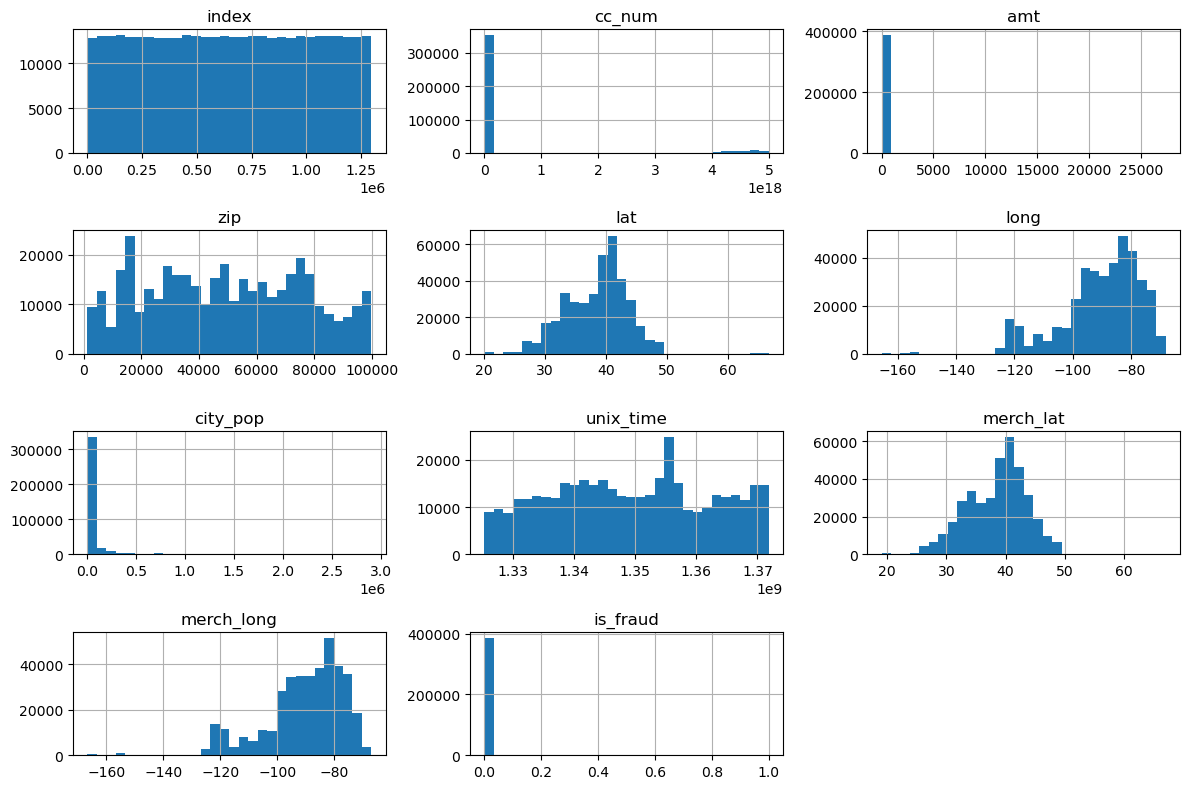

In [61]:
cc_data[numerical_cols].hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

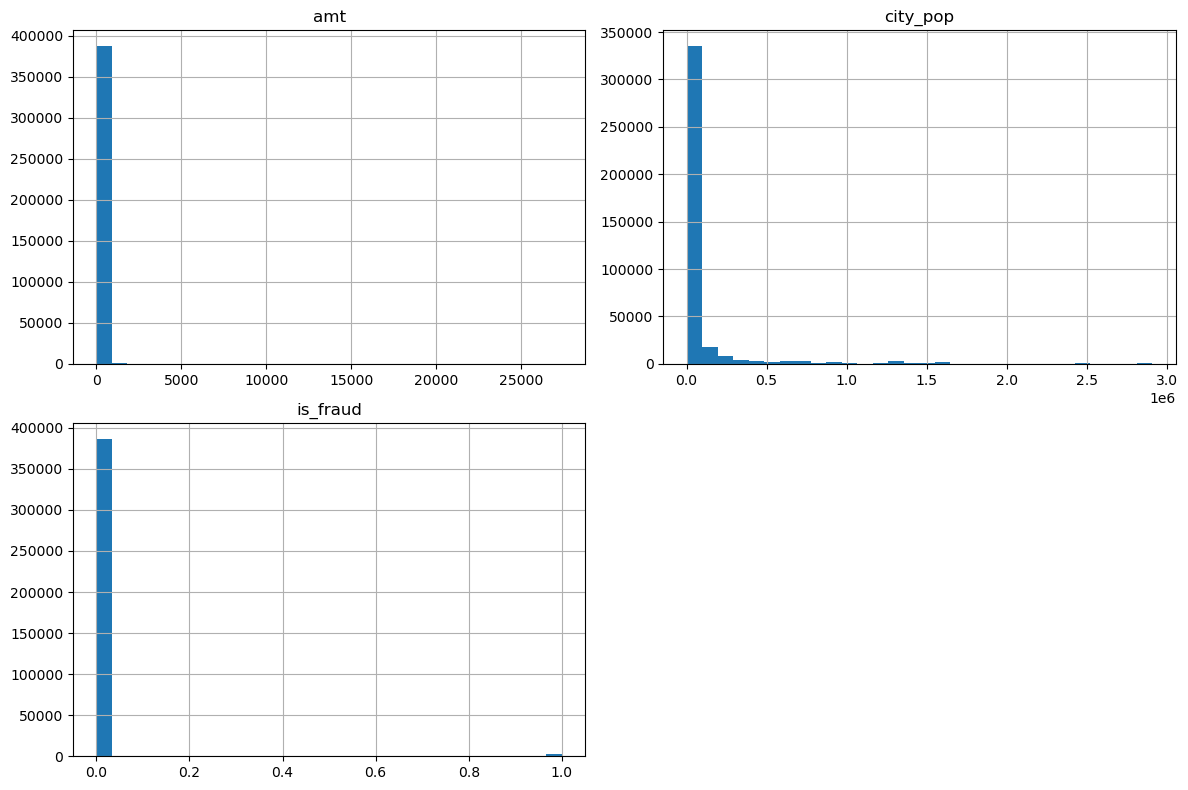

In [75]:
# Again ploting the relevant numerical variables

cc_data[['amt','city_pop','is_fraud']].hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

In [129]:
# Checking missing values
cc_data.isnull().sum()

index                    0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [85]:
# Summary statistics for numerical variables 
cc_data.describe()

,index,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,3.890020e+05,3.890020e+05,389002.000000,389002.000000,389002.000000,389002.000000,3.890020e+05,3.890020e+05,389002.000000,389002.000000,389002.000000
mean,6.485205e+05,4.191513e+17,70.442148,48818.064295,38.533121,-90.237664,8.868084e+04,1.349251e+09,38.531683,-90.236674,0.005789
std,3.745744e+05,1.311579e+18,162.203915,26879.383224,5.074596,13.745855,3.012101e+05,1.285085e+07,5.109400,13.757311,0.075866
min,1.100000e+01,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.325376e+09,19.029798,-166.669638,0.000000
25%,3.241842e+05,1.800430e+14,9.660000,26237.000000,34.620500,-96.798000,7.430000e+02,1.338751e+09,34.719394,-96.905445,0.000000
50%,6.486485e+05,3.521420e+15,47.570000,48174.000000,39.354300,-87.476900,2.456000e+03,1.349267e+09,39.361065,-87.446843,0.000000
75%,9.735032e+05,4.642260e+15,83.077500,72011.000000,41.940400,-80.158000,2.032800e+04,1.359460e+09,41.956012,-80.253831,0.000000
max,1.296674e+06,4.992350e+18,27390.120000,99783.000000,66.693300,-67.950300,2.906700e+06,1.371817e+09,67.064277,-66.956540,1.000000


In [83]:
cc_data[['amt','city_pop','is_fraud']].describe()

,amt,city_pop,is_fraud
count,389002.000000,3.890020e+05,389002.000000
mean,70.442148,8.868084e+04,0.005789
std,162.203915,3.012101e+05,0.075866
min,1.000000,2.300000e+01,0.000000
25%,9.660000,7.430000e+02,0.000000
50%,47.570000,2.456000e+03,0.000000
75%,83.077500,2.032800e+04,0.000000
max,27390.120000,2.906700e+06,1.000000


# Correlation

In [86]:
cc_data

,index,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,151888,2019/03/23 03:06,3.586010e+15,"fraud_Ferry, Lynch and Kautzer",misc_net,1.24,Crystal,Fuller,F,000 Jennifer Mills,...,47.4974,-122.0107,50489,Osteopath,1984/02/29,ff66e2310bf7a2a05e65d6b0a363aa5b,1332471978,47.352172,-121.644080,0
1,1185025,2020/05/10 11:28,4.671730e+15,fraud_Bogisich Inc,grocery_pos,112.57,Kenneth,Edwards,M,3653 Ryan Crossroad,...,40.8618,-85.6067,2304,Retail banker,1955/07/25,f1edcfa2102065f5f76375c2d20b9081,1368185292,40.265726,-85.914050,0
2,10818,2019/01/07 13:31,3.779930e+14,fraud_Mohr-Bayer,shopping_net,6.69,Nathan,Martinez,M,586 Thomas Cliffs,...,44.8755,-88.1555,5548,Mining engineer,1975/09/11,0caa0ca338d1d2903b92bb42d8905768,1325943086,44.512954,-88.693464,0
3,975275,2020/01/30 18:49,4.710830e+18,fraud_Langworth LLC,personal_care,100.69,Juan,Henry,M,9795 Lori Island Suite 346,...,48.8328,-108.3961,192,Further education lecturer,1964/01/04,c7d25a5388311ebd7f2eef77459376ac,1359571786,47.909634,-109.008657,0
4,346814,2019/06/12 03:04,3.723820e+14,fraud_Hills-Witting,shopping_net,7.80,Brent,Terrell,M,502 Rice Plaza Apt. 979,...,41.8948,-73.9767,2471,Heritage manager,1966/01/21,8e1306b47052ac10fe48512de79edf71,1339470288,41.534838,-74.449927,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
388997,1286992,2020/06/17 04:58,3.054650e+13,fraud_Jakubowski Group,food_dining,55.43,Nicholas,Tran,M,672 Randall Burg Suite 551,...,43.4512,-71.4890,7430,"Scientist, research (medical)",1955/01/13,b7d8dd8e9f941f316e5af3426dce91c0,1371445103,43.573310,-71.975075,0
388998,329380,2019/06/06 05:52,3.562260e+15,fraud_Lockman Ltd,grocery_pos,111.77,Anthony,Velasquez,M,609 Hunt Grove,...,37.6047,-85.4251,301,"Research officer, political party",1967/03/17,6226318c59455a8a56dadf44307031b6,1338961944,38.538512,-84.999516,0
388999,950878,2020/01/16 13:20,4.099710e+15,"fraud_Nicolas, Hills and McGlynn",entertainment,52.98,James,Stephens,M,1166 Castillo Mountains,...,38.2586,-78.4074,9815,"Designer, ceramics/pottery",1975/07/07,81287d23caeb5a07d0dd9ff7d61ddd9c,1358342419,38.423962,-78.882504,0
389000,958274,2020/01/20 08:51,6.761180e+11,"fraud_Reichert, Huels and Hoppe",shopping_net,3.38,Katelyn,Wise,F,674 Maureen Summit Apt. 276,...,44.9897,-122.6187,1252,"Engineer, petroleum",1937/02/06,b78283119c244578ee42b7f0f7708496,1358671894,45.180731,-122.515971,0


In [94]:
corr=cc_data[numerical_cols].corr()

In [95]:
corr

,index,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
index,1.000000,0.001289,0.000779,0.000874,-0.000193,-0.001494,-0.001800,0.998976,-0.000383,-0.001475,-0.006121
cc_num,0.001289,1.000000,0.002975,0.040485,-0.059182,-0.047587,-0.009125,0.001333,-0.058560,-0.047549,-0.001280
amt,0.000779,0.002975,1.000000,0.001756,-0.000445,-0.000517,0.007271,0.000780,-0.000314,-0.000578,0.210706
zip,0.000874,0.040485,0.001756,1.000000,-0.112567,-0.910295,0.078373,0.000905,-0.111689,-0.909470,-0.001220
lat,-0.000193,-0.059182,-0.000445,-0.112567,1.000000,-0.016080,-0.155972,-0.000150,0.993599,-0.015994,0.002643
long,-0.001494,-0.047587,-0.000517,-0.910295,-0.016080,1.000000,-0.053461,-0.001608,-0.016010,0.999119,0.001376
city_pop,-0.001800,-0.009125,0.007271,0.078373,-0.155972,-0.053461,1.000000,-0.001766,-0.154767,-0.053468,0.001176
unix_time,0.998976,0.001333,0.000780,0.000905,-0.000150,-0.001608,-0.001766,1.000000,-0.000354,-0.001582,-0.006562
merch_lat,-0.000383,-0.058560,-0.000314,-0.111689,0.993599,-0.016010,-0.154767,-0.000354,1.000000,-0.015932,0.002406
merch_long,-0.001475,-0.047549,-0.000578,-0.909470,-0.015994,0.999119,-0.053468,-0.001582,-0.015932,1.000000,0.001351


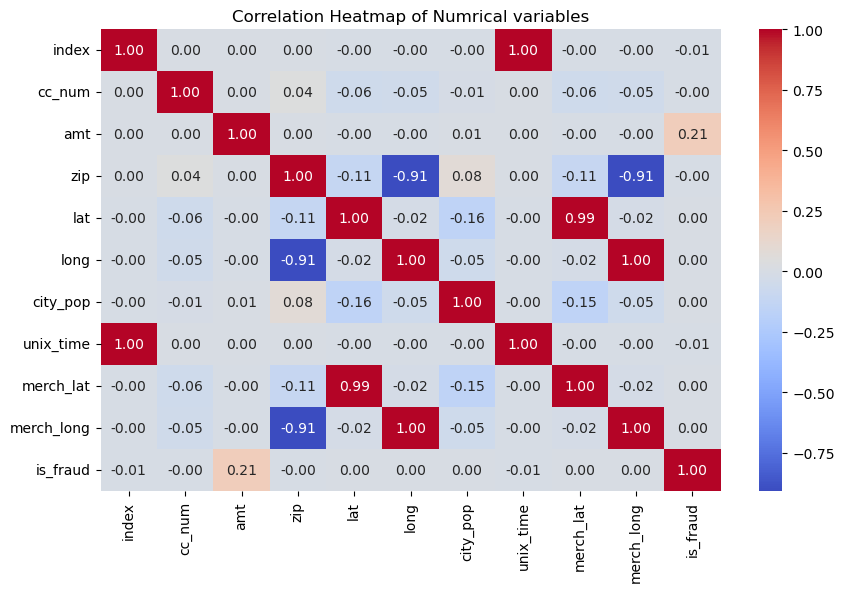

In [103]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numrical variables")
plt.show()

In [111]:
# Distribution of amt across fraud categories(fraud vs non-fraud)

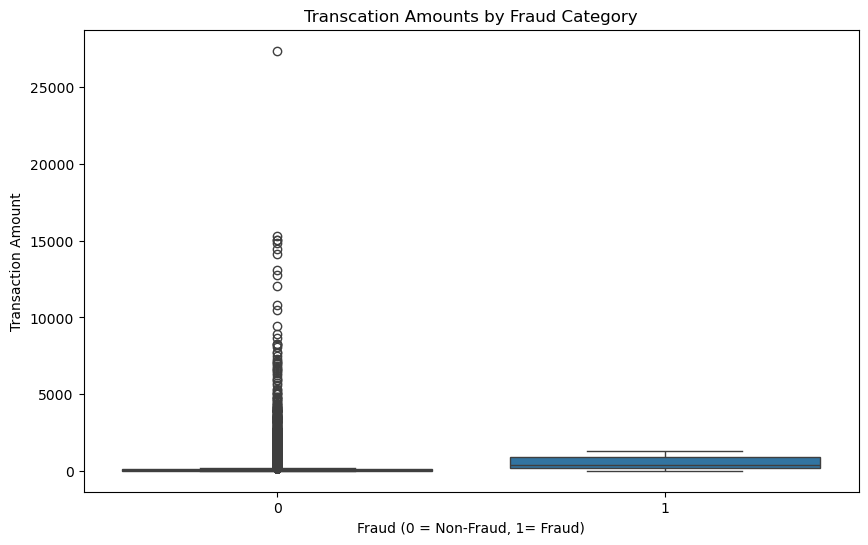

In [110]:
plt.figure(figsize=(10,6))
sns.boxplot(x='is_fraud', y='amt', data=cc_data)
plt.title ("Transcation Amounts by Fraud Category")
plt.xlabel("Fraud (0 = Non-Fraud, 1= Fraud)")
plt.ylabel("Transaction Amount")
plt.show()

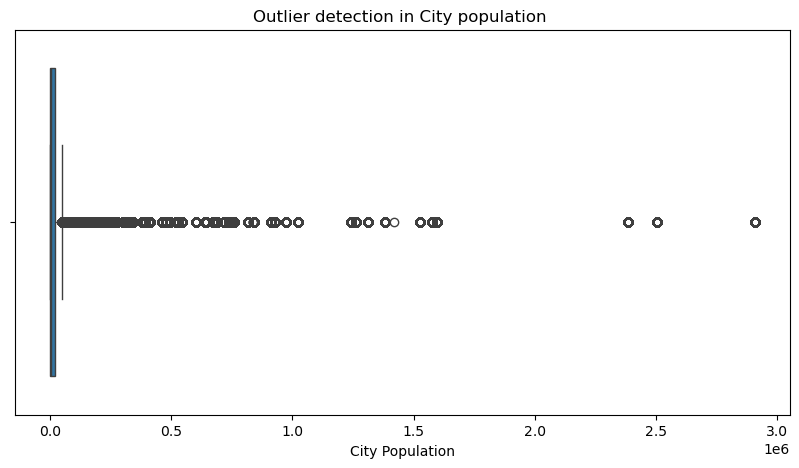

In [124]:
# Outlier detection in City Population

plt.figure(figsize=(10,5))
sns.boxplot(x=cc_data['city_pop'])
plt.title('Outlier detection in City population ')
plt.xlabel('City Population')
plt.show()

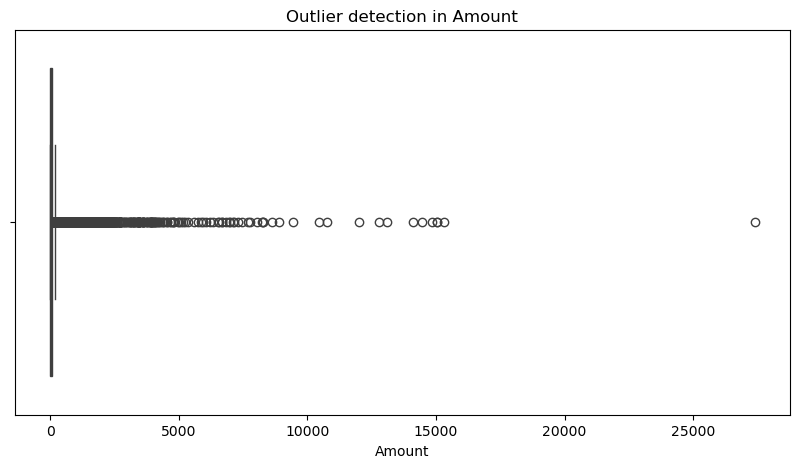

In [127]:
# Outlier detection in Transaction Amount

plt.figure(figsize=(10,5))
sns.boxplot(x=cc_data['amt'])
plt.title('Outlier detection in Amount')
plt.xlabel('Amount')
plt.show()

In [130]:
# Convert transaction date to datetime

cc_data['trans_date_trans_time']= pd.to_datetime(cc_data['trans_date_trans_time'])


In [34]:
# Extract useful time features 
cc_data['year'] = cc_data['trans_date_trans_time'].dt.year
cc_data['month'] = cc_data['trans_date_trans_time'].dt.month
cc_data['day'] = cc_data['trans_date_trans_time'].dt.day
cc_data['hour'] = cc_data['trans_date_trans_time'].dt.hour

In [35]:
cc_data

,index,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,hour
0,151888,2019-03-23 03:06:00,3.586010e+15,"fraud_Ferry, Lynch and Kautzer",misc_net,1.24,Crystal,Fuller,F,000 Jennifer Mills,...,1984/02/29,ff66e2310bf7a2a05e65d6b0a363aa5b,1332471978,47.352172,-121.644080,0,2019,3,23,3
1,1185025,2020-05-10 11:28:00,4.671730e+15,fraud_Bogisich Inc,grocery_pos,112.57,Kenneth,Edwards,M,3653 Ryan Crossroad,...,1955/07/25,f1edcfa2102065f5f76375c2d20b9081,1368185292,40.265726,-85.914050,0,2020,5,10,11
2,10818,2019-01-07 13:31:00,3.779930e+14,fraud_Mohr-Bayer,shopping_net,6.69,Nathan,Martinez,M,586 Thomas Cliffs,...,1975/09/11,0caa0ca338d1d2903b92bb42d8905768,1325943086,44.512954,-88.693464,0,2019,1,7,13
3,975275,2020-01-30 18:49:00,4.710830e+18,fraud_Langworth LLC,personal_care,100.69,Juan,Henry,M,9795 Lori Island Suite 346,...,1964/01/04,c7d25a5388311ebd7f2eef77459376ac,1359571786,47.909634,-109.008657,0,2020,1,30,18
4,346814,2019-06-12 03:04:00,3.723820e+14,fraud_Hills-Witting,shopping_net,7.80,Brent,Terrell,M,502 Rice Plaza Apt. 979,...,1966/01/21,8e1306b47052ac10fe48512de79edf71,1339470288,41.534838,-74.449927,0,2019,6,12,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
388997,1286992,2020-06-17 04:58:00,3.054650e+13,fraud_Jakubowski Group,food_dining,55.43,Nicholas,Tran,M,672 Randall Burg Suite 551,...,1955/01/13,b7d8dd8e9f941f316e5af3426dce91c0,1371445103,43.573310,-71.975075,0,2020,6,17,4
388998,329380,2019-06-06 05:52:00,3.562260e+15,fraud_Lockman Ltd,grocery_pos,111.77,Anthony,Velasquez,M,609 Hunt Grove,...,1967/03/17,6226318c59455a8a56dadf44307031b6,1338961944,38.538512,-84.999516,0,2019,6,6,5
388999,950878,2020-01-16 13:20:00,4.099710e+15,"fraud_Nicolas, Hills and McGlynn",entertainment,52.98,James,Stephens,M,1166 Castillo Mountains,...,1975/07/07,81287d23caeb5a07d0dd9ff7d61ddd9c,1358342419,38.423962,-78.882504,0,2020,1,16,13
389000,958274,2020-01-20 08:51:00,6.761180e+11,"fraud_Reichert, Huels and Hoppe",shopping_net,3.38,Katelyn,Wise,F,674 Maureen Summit Apt. 276,...,1937/02/06,b78283119c244578ee42b7f0f7708496,1358671894,45.180731,-122.515971,0,2020,1,20,8


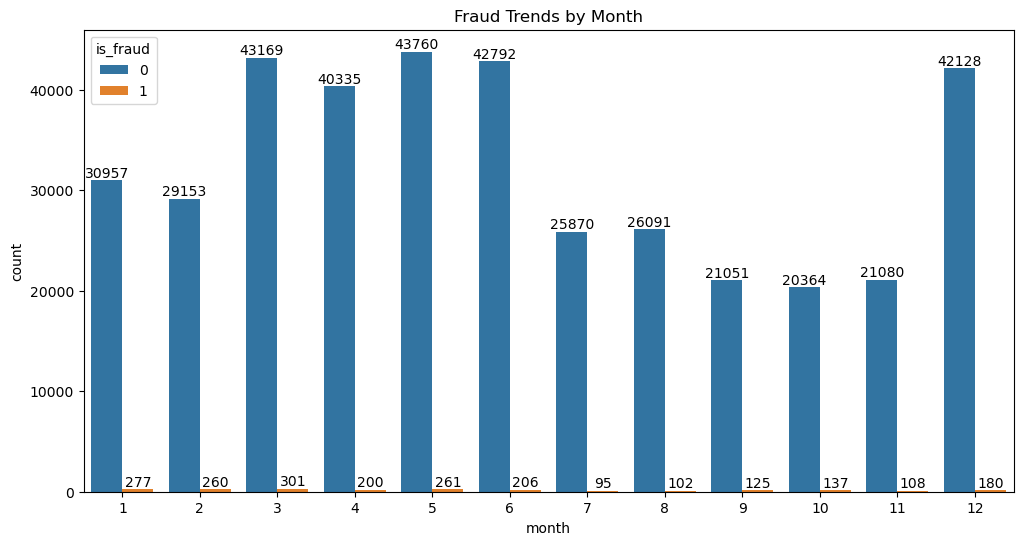

In [36]:
# Fraud trend over Months
plt.figure(figsize=(12,6))
ax=sns.countplot(x='month', hue='is_fraud', data= cc_data)
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Fraud Trends by Month")
plt.show()

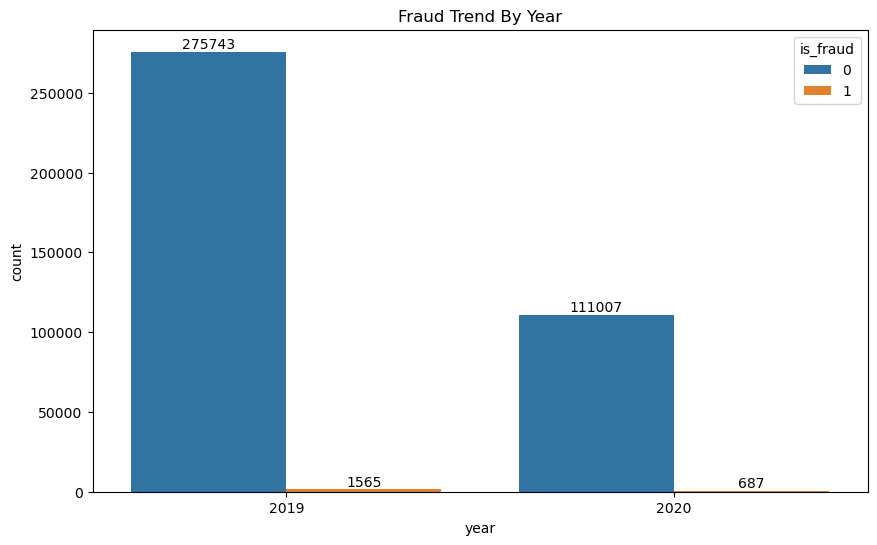

In [37]:
# Fraud trend over years

plt.figure(figsize=(10,6))
ax=sns.countplot(x='year', hue='is_fraud',  data = cc_data)
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Fraud Trend By Year')
plt.show()

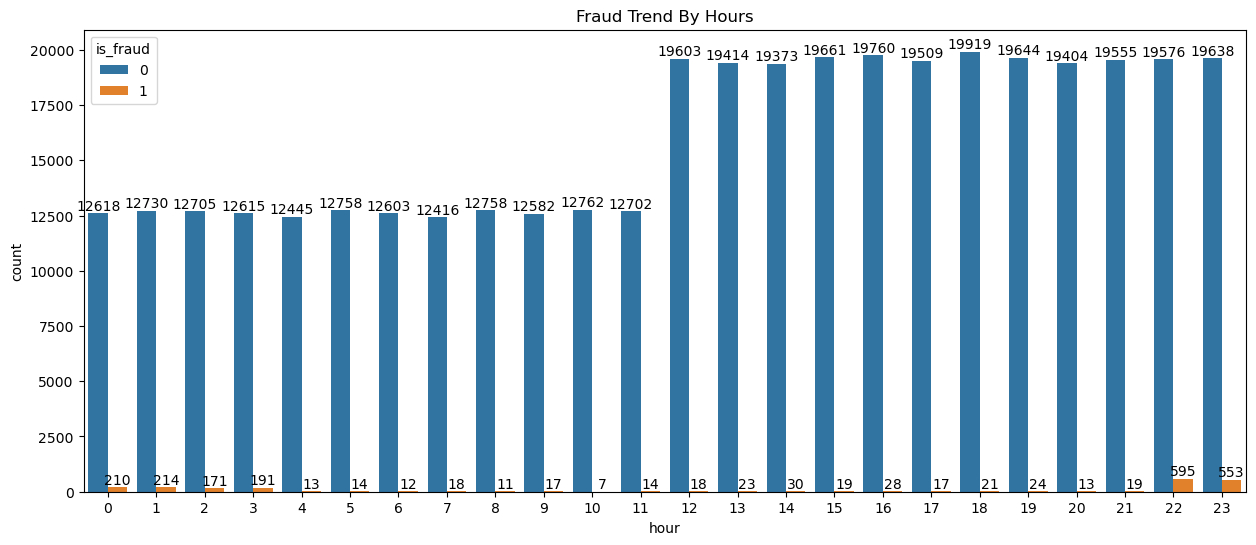

In [39]:
plt.figure(figsize=(15,6))
ax=sns.countplot(x='hour', hue='is_fraud',  data = cc_data)
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Fraud Trend By Hours')
plt.show()

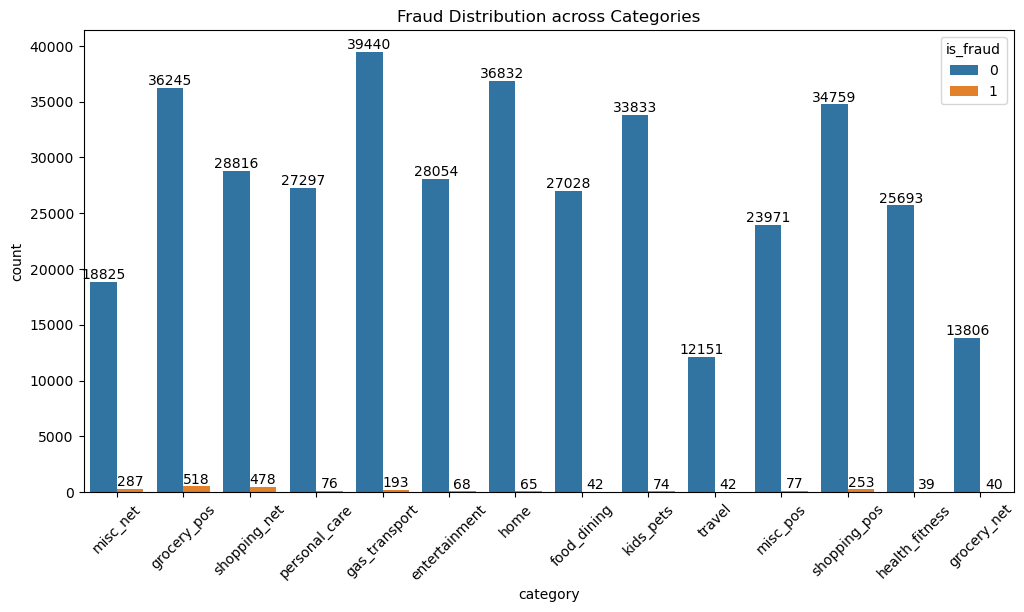

In [14]:
#Fraud distributes across different categories

#fraud distributiion by category

plt.figure(figsize=(12,6))
ax=sns.countplot(x='category', hue = 'is_fraud', data= cc_data)
for container in ax.containers:
    ax.bar_label(container)

plt.title('Fraud Distribution across Categories')
plt.xticks(rotation=45)
plt.show()

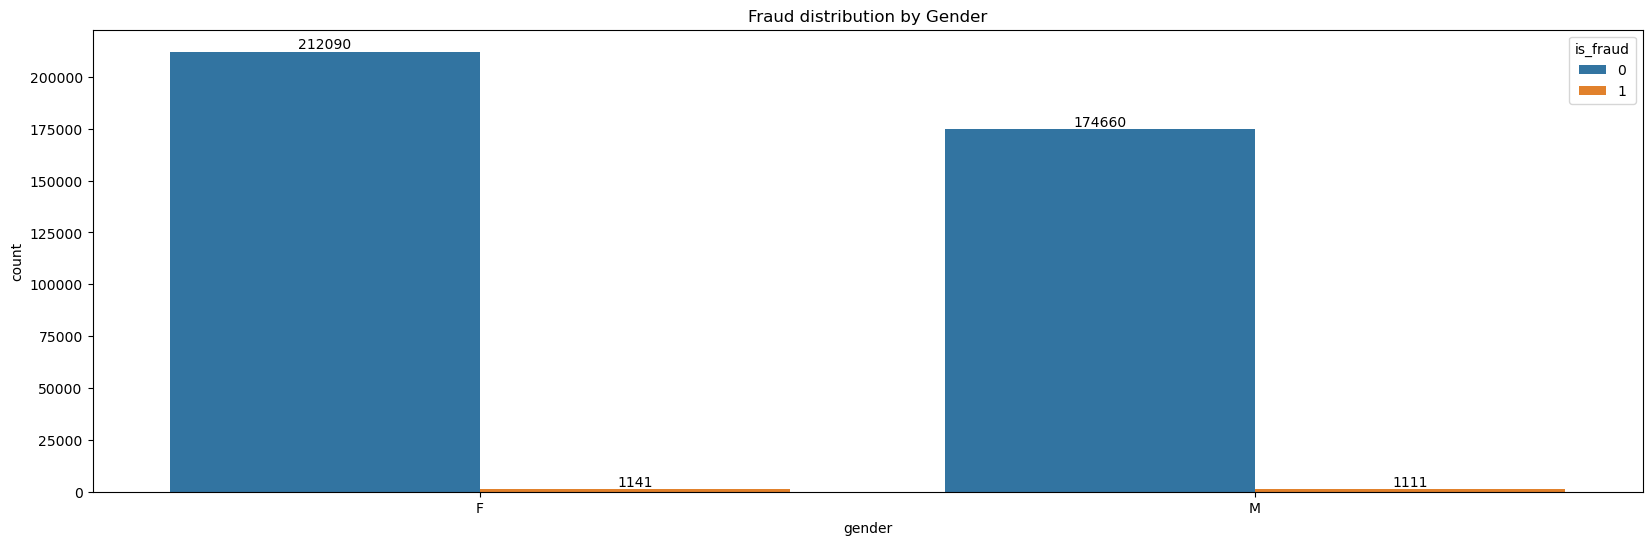

In [19]:
# Fraud distribution across Gender

plt.figure(figsize=(20,6))
ax=sns.countplot(x='gender', hue='is_fraud', data= cc_data)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Fraud distribution by Gender')
plt.show()